# Exploration: Regional Data
**REGIONAL DATA**

---

**Zweck:** Die jährlichen Regionaldaten (Prognoseraum, Bezirksregion, Planungsraum) durchleuchten, vor allem die offizielle Hilfsfrist-Quote.  
**Input:** `fct_timegoal_region_yearly`, `dim_region`, `stg_regional_*` und `stg_missions` aus `data/berlin_emergency.duckdb`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen; Lesehilfe für die Karte.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

## Structure

### Levels and Years

Drei LOR-Ebenen (Lebensweltlich orientierte Räume): Prognoseraum (4 Stellen), Bezirksregion (6), Planungsraum (8). Jede Ebene hat dieselben 28 Kennzahlen. Wir nutzen die Gold-Tabelle `fct_timegoal_region_yearly`, für Spalteninhalte die Staging-Tabellen.

In [2]:
df_levels = q("""
    select region_level, data_year as year, count(*) as regions, sum(mission_count_all) as missions,
           sum(mission_count_ems_critical) as ems_critical, sum(ems_critical_timegoal_computed) as computed,
           sum(ems_critical_timegoal_reached) as reached
    from fct_timegoal_region_yearly group by all order by region_level, year
""")
show_df(df_levels)

,region_level,year,regions,missions,ems_critical,computed,reached
0,district_area,2024,143,532576.00,458119.00,414638.00,196136.00
1,district_area,2025,143,555082.00,328279.00,290464.00,174627.00
2,district_area,2026,143,439181.00,210494.00,183362.00,124368.00
3,planning_room,2024,542,532576.00,458119.00,414638.00,196136.00
4,planning_room,2025,542,555082.00,328279.00,290464.00,174627.00
5,planning_room,2026,542,439181.00,210494.00,183362.00,124368.00
6,prediction_area,2024,58,532576.00,458119.00,414638.00,196136.00
7,prediction_area,2025,58,555082.00,328279.00,290464.00,174627.00
8,prediction_area,2026,58,439181.00,210494.00,183362.00,124368.00


Die drei Ebenen müssen denselben Einsätzen entsprechen: Summen je Jahr identisch? Und: wie viel der Einsätze stecken in Jahr, Ebene und Region?

In [3]:
df_levels_same = df_levels.groupby('year')[['missions', 'ems_critical', 'computed', 'reached']].nunique()
show_df(df_levels_same.reset_index().rename(columns=lambda c: f'{c}_distinct' if c != 'year' else c))
success('all levels agree') if (df_levels_same == 1).all().all() else warn('levels differ')

,year,missions_distinct,ems_critical_distinct,computed_distinct,reached_distinct
0,2024,1,1,1,1
1,2025,1,1,1,1
2,2026,1,1,1,1


✓  all levels agree


### Hierarchy

In [4]:
df_hier = q("""
    select region_level, count(*) as regions, count(distinct district_code) as districts,
           count(distinct prediction_area_id) as prediction_areas, count(distinct district_area_id) as district_areas,
           min(first_year) as first_year, max(last_year) as last_year
    from dim_region group by 1 order by 2
""")
show_df(df_hier)

,region_level,regions,districts,prediction_areas,district_areas,first_year,last_year
0,prediction_area,58,12,0,0,2024,2026
1,district_area,143,12,58,0,2024,2026
2,planning_room,542,12,58,143,2024,2026


Die IDs sind stabil (jede Region taucht in jedem Jahr auf). Die Hierarchie steckt in den Präfixen: die ersten zwei Stellen sind der Bezirk.

### Columns and Profile


───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,542,
1,columns,33,
2,duplicates,0,0.0%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  MISSING VALUES  ─────────────────────────────────────────


,column,missing_cnt,missing_pct
0,response_time_fire_time_to_full_crew_std,62,11.44%
1,response_time_fire_time_to_first_ladder_std,56,10.33%
2,response_time_ems_critical_cpr_std,45,8.30%
3,response_time_fire_time_to_full_crew_median,25,4.61%
4,response_time_fire_time_to_full_crew_mean,25,4.61%
5,response_time_fire_time_to_first_ladder_mean,24,4.43%
6,response_time_fire_time_to_first_ladder_median,24,4.43%
7,response_time_ems_critical_cpr_median,13,2.40%
8,response_time_ems_critical_cpr_mean,13,2.40%
9,response_time_fire_time_to_first_pump_std,8,1.48%


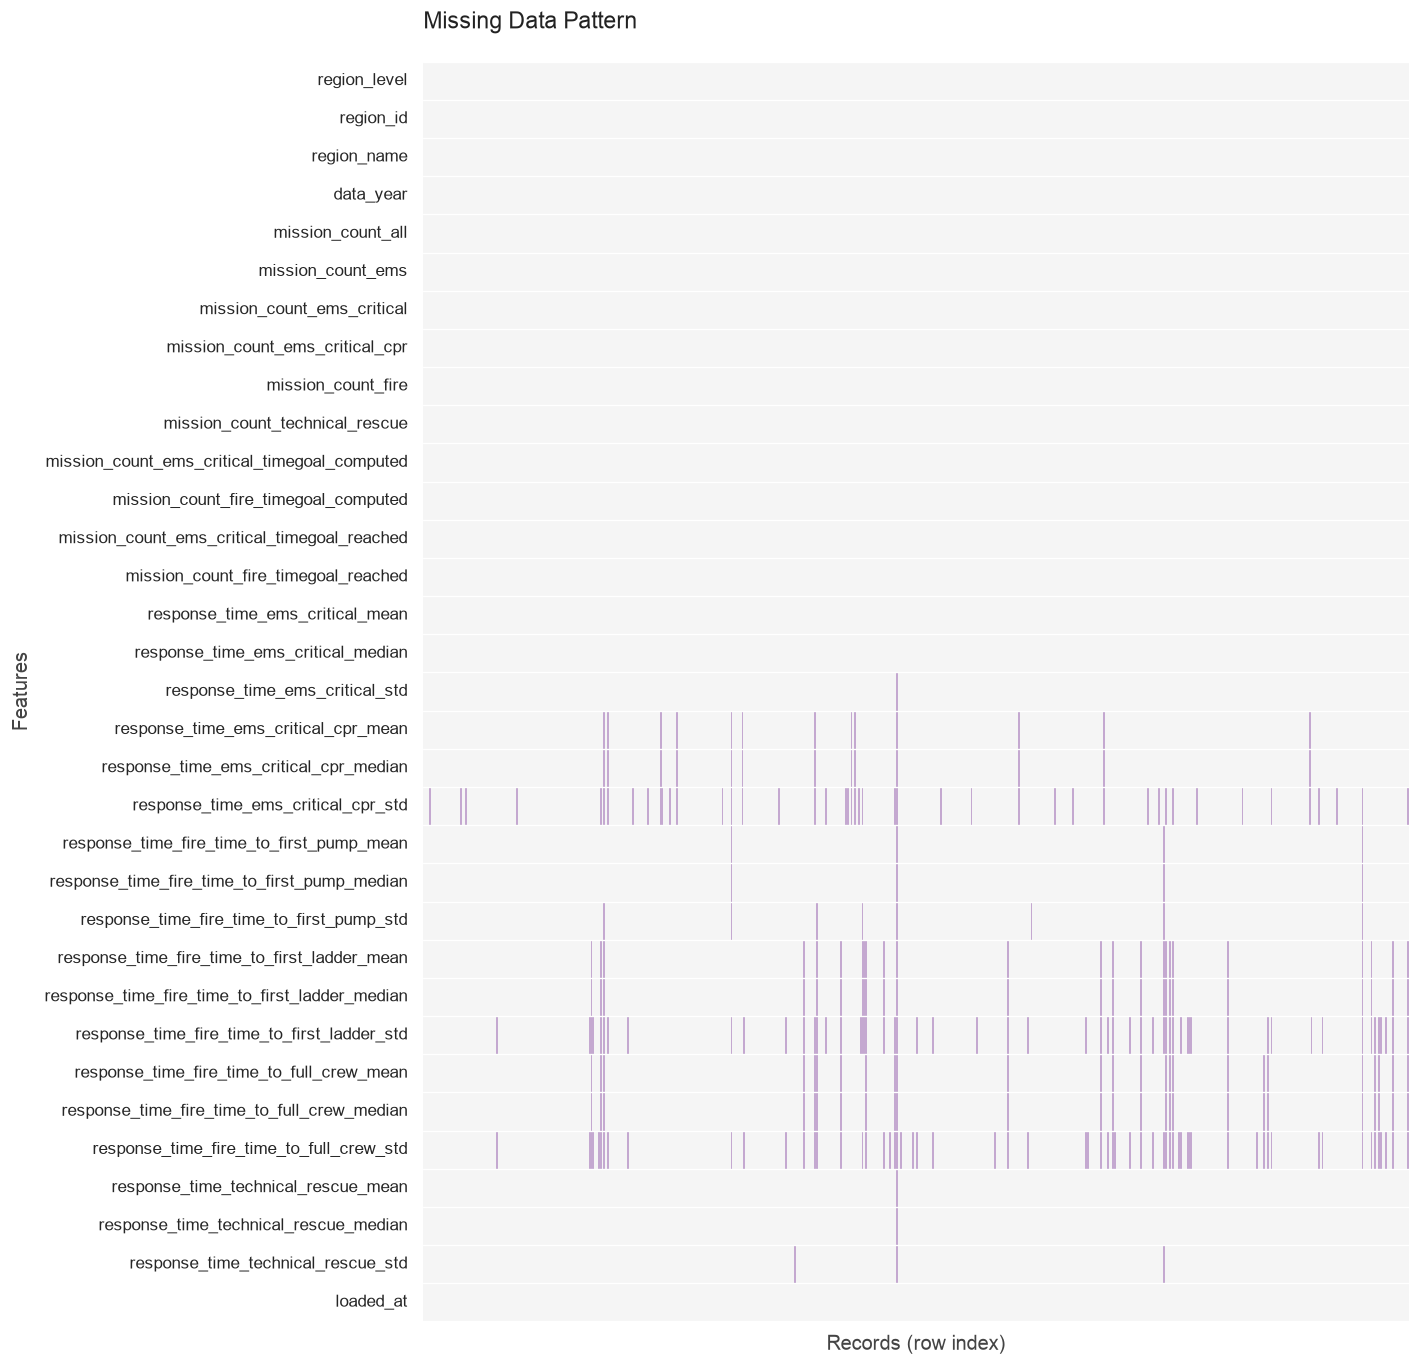

In [5]:
df_pr = q('select * from stg_regional_planning_room where data_year = 2025')
inspect(df_pr, sections=['dimensions', 'missing'])

In [6]:
inspect(df_pr, sections=['numeric'], columns=['mission_count_all', 'mission_count_ems_critical', 'mission_count_ems_critical_timegoal_computed',
                                                  'mission_count_ems_critical_timegoal_reached', 'response_time_ems_critical_median'])


───  NUMERIC STATS  ──────────────────────────────────────────


,column,missing_pct,count,mean,median,std,min,25%,75%,max,mean_median_diff,skewness
0,mission_count_all,0.00%,542.00,1024.14,956.50,554.00,1.00,656.75,1258.00,5452.00,67.64,1.90
1,mission_count_ems_critical,0.00%,542.00,605.68,565.00,317.94,1.00,384.25,764.50,2984.00,40.68,1.67
2,mission_count_ems_critical_timegoal_computed,0.00%,542.00,535.91,496.00,282.62,1.00,340.00,680.00,2615.00,39.91,1.64
3,mission_count_ems_critical_timegoal_reached,0.00%,542.00,322.19,288.50,206.44,0.00,180.50,416.50,1862.00,33.69,1.89
4,response_time_ems_critical_median,0.00%,542.00,595.40,586.00,67.08,454.50,548.12,639.00,964.00,9.40,0.71


## Region Size

Wie viele Einsätze stecken in einer Region? Kleine Regionen haben instabile Quoten, das entscheidet, wie wir die Karte lesen.

In [7]:
df_size = q("""
    select data_year as year,
           count(*) filter (where ems_critical_timegoal_computed < 30) as under_30,
           count(*) filter (where ems_critical_timegoal_computed between 30 and 99) as from_30_to_99,
           count(*) filter (where ems_critical_timegoal_computed between 100 and 299) as from_100_to_299,
           count(*) filter (where ems_critical_timegoal_computed >= 300) as from_300,
           count(*) as regions
    from fct_timegoal_region_yearly where region_level = 'planning_room' group by 1 order by 1
""")
show_df(df_size)

,year,under_30,from_30_to_99,from_100_to_299,from_300,regions
0,2024,4,2,34,502,542
1,2025,4,4,96,438,542
2,2026,4,22,222,294,542


Text(0.5, 0, 'missions')

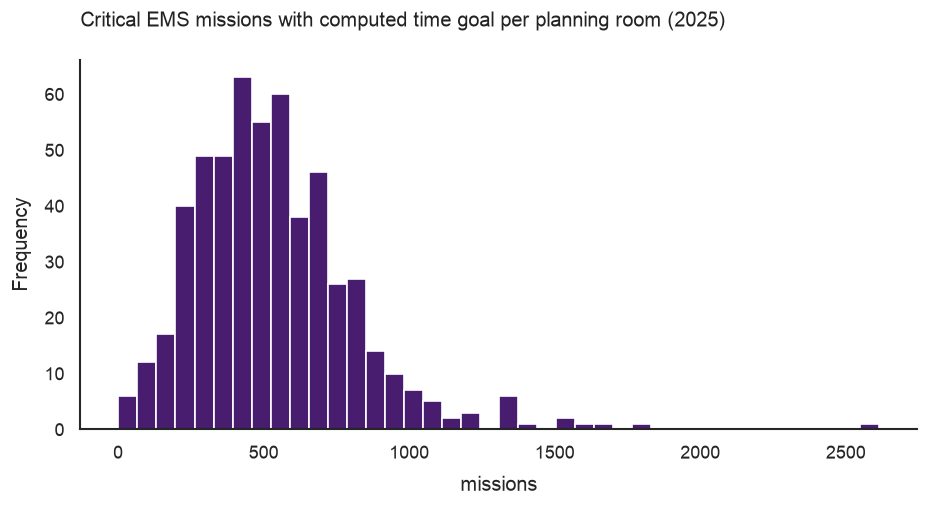

In [8]:
df_pr_size = q("select ems_critical_timegoal_computed as computed from fct_timegoal_region_yearly where region_level = 'planning_room' and data_year = 2025")
ax = df_pr_size['computed'].plot(kind='hist', bins=40, figsize=(9, 4), title='Critical EMS missions with computed time goal per planning room (2025)')
ax.set_xlabel('missions')

## Time Goal Quote

### City-wide

,year,computed,reached,ems_quote_pct,computed_of_critical_pct,fire_quote_pct
0,2024,414638.00,196136.00,47.30%,90.50%,80.00%
1,2025,290464.00,174627.00,60.10%,88.50%,83.00%
2,2026,183362.00,124368.00,67.80%,87.10%,83.90%


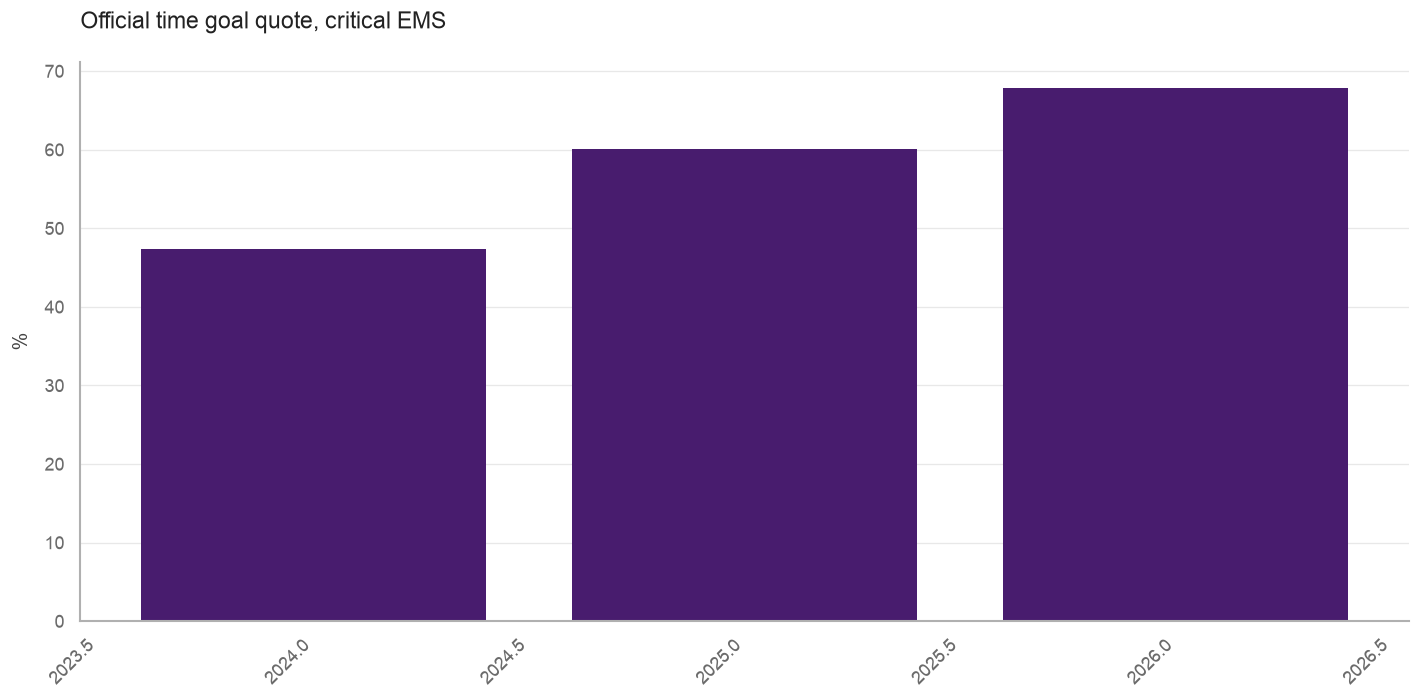

In [9]:
df_quote = q("""
    select data_year as year, sum(ems_critical_timegoal_computed) as computed, sum(ems_critical_timegoal_reached) as reached,
           round(100.0 * sum(ems_critical_timegoal_reached) / sum(ems_critical_timegoal_computed), 1) as ems_quote_pct,
           round(100.0 * sum(ems_critical_timegoal_computed) / sum(mission_count_ems_critical), 1) as computed_of_critical_pct,
           round(100.0 * sum(fire_timegoal_reached) / sum(fire_timegoal_computed), 1) as fire_quote_pct
    from fct_timegoal_region_yearly where region_level = 'district_area' group by 1 order by 1
""")
show_df(df_quote)
fig, ax = bar(df_quote, x='year', y='ems_quote_pct', title='Official time goal quote, critical EMS', ylabel='%')

### By District

In [10]:
df_dq = q("""
    select d.district_name, f.data_year as year,
           round(100.0 * sum(f.ems_critical_timegoal_reached) / sum(f.ems_critical_timegoal_computed), 1) as quote_pct
    from fct_timegoal_region_yearly f join dim_region r using (region_level, region_id) join dim_district d on r.district_code = d.district_code
    where f.region_level = 'district_area' group by all
""").pivot(index='district_name', columns='year', values='quote_pct')
df_dq['change_2025_to_2026'] = (df_dq[2026] - df_dq[2025]).round(1)
show_df(df_dq.sort_values(2026).reset_index())

year,district_name,2024,2025,2026,change_2025_to_2026
0,Marzahn-Hellersdorf,36.70,48.90,57.50,8.60
1,Treptow-Köpenick,35.70,50.30,58.50,8.20
2,Reinickendorf,42.60,54.50,62.30,7.80
3,Steglitz-Zehlendorf,43.40,55.30,63.10,7.80
4,Lichtenberg,39.50,52.10,64.60,12.50
5,Neukölln,46.20,61.30,66.30,5.00
6,Pankow,45.00,57.20,67.30,10.10
7,Spandau,49.80,62.10,68.60,6.50
8,Tempelhof-Schöneberg,50.80,64.90,69.70,4.80
9,Charlottenburg-Wilmersdorf,53.00,64.90,71.50,6.60


### By Mission Type

Die Regionaldaten führen Hilfsfrist-Zähler nur für den kritischen Rettungsdienst und für Brände. Für die technische Hilfe gibt es nur Zeit-Statistiken (keine Frist vereinbart). Stadtweit je Einsatzart:

In [11]:
df_type = q("""
    select data_year as year,
           round(100.0 * sum(ems_critical_timegoal_reached) / sum(ems_critical_timegoal_computed), 1) as ems_quote_pct,
           round(100.0 * sum(fire_timegoal_reached) / sum(fire_timegoal_computed), 1) as fire_quote_pct,
           round(median(response_time_ems_critical_median) filter (where ems_critical_timegoal_computed >= 30), 0) as ems_median_s,
           round(median(response_time_fire_time_to_first_pump_median) filter (where fire_timegoal_computed >= 10), 0) as fire_first_pump_median_s,
           round(median(response_time_technical_rescue_median) filter (where mission_count_all >= 30), 0) as technical_median_s
    from fct_timegoal_region_yearly where region_level = 'planning_room' group by 1 order by 1
""")
show_df(df_type)

,year,ems_quote_pct,fire_quote_pct,ems_median_s,fire_first_pump_median_s,technical_median_s
0,2024,47.30%,80.00%,612.00,575.00,816.00
1,2025,60.10%,83.00%,585.00,562.00,786.00
2,2026,67.80%,83.90%,574.00,548.00,809.00


Die Quote der Brandbekämpfung (Frist 14 Funktionen in 15 Minuten) bleibt über die Jahre nahezu stabil, weil sich ihre Grundgesamtheit nicht ändert. Nach Bezirk:

In [12]:
df_fire_d = q("""
    select d.district_name, f.data_year as year,
           round(100.0 * sum(f.fire_timegoal_reached) / sum(f.fire_timegoal_computed), 1) as fire_quote_pct
    from fct_timegoal_region_yearly f join dim_region r using (region_level, region_id) join dim_district d on r.district_code = d.district_code
    where f.region_level = 'district_area' group by all
""").pivot(index='district_name', columns='year', values='fire_quote_pct')
show_df(df_fire_d.sort_values(2026).reset_index())

year,district_name,2024,2025,2026
0,Treptow-Köpenick,54.70,63.60,58.00
1,Steglitz-Zehlendorf,72.40,74.00,75.60
2,Reinickendorf,74.40,79.90,76.30
3,Spandau,73.00,69.60,79.60
4,Marzahn-Hellersdorf,65.90,70.40,79.90
5,Lichtenberg,70.60,74.40,80.30
6,Tempelhof-Schöneberg,78.70,84.30,80.60
7,Pankow,76.70,77.80,80.70
8,Neukölln,81.90,86.60,84.20
9,Friedrichshain-Kreuzberg,85.10,87.40,89.80


### Spread between Regions

In [13]:
df_spread = q("""
    select region_level, data_year as year, count(*) as regions_30plus,
           round(100 * min(ems_critical_timegoal_quote), 1) as min_pct,
           round(100 * quantile_cont(ems_critical_timegoal_quote, 0.25), 1) as p25_pct,
           round(100 * median(ems_critical_timegoal_quote), 1) as median_pct,
           round(100 * quantile_cont(ems_critical_timegoal_quote, 0.75), 1) as p75_pct,
           round(100 * max(ems_critical_timegoal_quote), 1) as max_pct
    from fct_timegoal_region_yearly where ems_critical_timegoal_computed >= 30 group by all order by 1, 2
""")
show_df(df_spread)

,region_level,year,regions_30plus,min_pct,p25_pct,median_pct,p75_pct,max_pct
0,district_area,2024,143,3.40%,35.30%,46.10%,53.70%,70.00%
1,district_area,2025,143,5.30%,48.80%,59.30%,67.80%,83.00%
2,district_area,2026,143,22.00%,57.40%,65.80%,74.70%,86.40%
3,planning_room,2024,538,3.10%,35.10%,47.40%,56.10%,72.70%
4,planning_room,2025,538,4.90%,49.00%,61.60%,69.30%,84.70%
5,planning_room,2026,538,15.40%,57.80%,69.30%,76.90%,90.20%
6,prediction_area,2024,58,23.60%,37.80%,46.90%,53.10%,67.10%
7,prediction_area,2025,58,31.50%,52.10%,58.50%,66.80%,79.70%
8,prediction_area,2026,58,40.00%,59.50%,65.20%,74.10%,84.40%


### Stability of the Pattern

Verschiebt sich das Niveau, bleibt die Rangfolge der Regionen? Rangkorrelation (Spearman, über Ränge und Pearson berechnet) der Quote je Planungsraum zwischen den Jahren (nur Regionen mit mindestens 30 Einsätzen in beiden Jahren).

In [14]:
df_wide = q("""
    select region_id, data_year, ems_critical_timegoal_quote as quote, ems_critical_timegoal_computed as n
    from fct_timegoal_region_yearly where region_level = 'planning_room'
""")
w_q = df_wide.pivot(index='region_id', columns='data_year', values='quote')
w_n = df_wide.pivot(index='region_id', columns='data_year', values='n')
rows = []
for a, b in [(2024, 2025), (2025, 2026), (2024, 2026)]:
    ok = (w_n[a] >= 30) & (w_n[b] >= 30)
    rows.append({'years': f'{a} vs {b}', 'regions': int(ok.sum()), 'spearman': round(w_q.loc[ok, a].rank().corr(w_q.loc[ok, b].rank()), 3),
                 'mean_shift_pct_points': round(100 * (w_q.loc[ok, b] - w_q.loc[ok, a]).mean(), 1)})
show_df(pd.DataFrame(rows))

,years,regions,spearman,mean_shift_pct_points
0,2024 vs 2025,538,0.95,12.80%
1,2025 vs 2026,538,0.93,7.70%
2,2024 vs 2026,538,0.92,20.40%


## Response Time in the Regions

In [15]:
df_rt = q("""
    select data_year as year, round(median(response_time_ems_critical_median), 0) as median_of_region_medians_s,
           round(min(response_time_ems_critical_median), 0) as min_s, round(max(response_time_ems_critical_median), 0) as max_s,
           round(corr(response_time_ems_critical_median, ems_critical_timegoal_quote), 2) as corr_median_vs_quote
    from fct_timegoal_region_yearly where region_level = 'planning_room' and ems_critical_timegoal_computed >= 30 group by 1 order by 1
""")
show_df(df_rt)

,year,median_of_region_medians_s,min_s,max_s,corr_median_vs_quote
0,2024,612.00,471.00,998.00,-0.97
1,2025,585.00,455.00,964.00,-0.97
2,2026,574.00,428.00,796.00,-0.96


## Reconciliation with Mission Data

In [16]:
df_rec = q("""
    with r as (select data_year as year, sum(mission_count_all) as regional_all, sum(mission_count_ems) as regional_ems
               from fct_timegoal_region_yearly where region_level = 'district_area' group by 1),
         m as (select source_year as year, count(*) as detail_all, count(*) filter (where mission_type like 'Rettungsdienst%') as detail_ems
               from stg_missions group by 1)
    select year, regional_all, detail_all, round(100.0 * (regional_all - detail_all) / detail_all, 2) as all_diff_pct,
           regional_ems, detail_ems, round(100.0 * (regional_ems - detail_ems) / detail_ems, 2) as ems_diff_pct
    from r join m using (year) order by year
""")
show_df(df_rec)

,year,regional_all,detail_all,all_diff_pct,regional_ems,detail_ems,ems_diff_pct
0,2024,532576.00,532575,0.00%,480087.00,480087,0.00%
1,2025,555082.00,556864,-0.32%,500552.00,501943,-0.28%
2,2026,439181.00,439179,0.00%,396217.00,396217,0.00%


## Findings

### Content

Jahresaggregate der Berliner Feuerwehr auf drei LOR-Ebenen (58 Prognoseräume, 143 Bezirksregionen, 542 Planungsräume), Stand LOR 01.01.2021, für 2024, 2025 und das laufende Jahr 2026. Je Region: Einsatzzahlen nach Art, Antwortzeit-Statistik (Mittelwert, Median, Standardabweichung) und die Hilfsfrist-Zähler (`timegoal_computed` und `timegoal_reached`) für kritischen Rettungsdienst und Brand.

### Usefulness

* **Einzige Quelle der offiziellen Hilfsfrist-Quote** und die einzige mit geografischer Tiefe unterhalb des Bezirks.
* **Karte:** Die IDs sind stabil und stimmen mit den LOR-Polygonen überein; die drei Ebenen summieren sich auf dieselben Einsätze, wir können die Auflösung frei wählen.
* **Referenz für die eigene Näherung:** Die Quote ist die Messlatte, an der wir die Näherung aus den Einzeleinsätzen prüfen.

### Limits

* **Nur ab 2024 und nur jährlich.** Kein Zeitverlauf, keine Saison; 2026 ist unvollständig.
* **Definitionsbruch am 25.03.2025:** Seit diesem Stichtag klassifiziert die BF Einsätze in Notfallkategorien; die Zahl kritischer Einsätze schrumpft (siehe `01_exploration_daily`), die Quote steigt scheinbar. Niveaus verschiedener Jahre sind nicht vergleichbar, nur Muster. 2025 enthält beide Definitionen.
* **Einsatzarten:** Hilfsfrist-Zähler gibt es nur für kritischen Rettungsdienst und Brand. Für technische Hilfe sind weder Frist noch Zähler vorhanden.
* **Kleine Regionen:** Einzelne Planungsräume haben wenige oder gar keine auswertbaren Einsätze (immer dieselben vier unter 30). Ihre Quoten sind instabil und werden in der Karte mit Vorsicht gelesen.
* **Nicht jeder kritische Einsatz zählt:** Die Frist wird nur berechnet, wenn alle Zeitstempel vorliegen (rund neun von zehn Einsätzen).
* **Keine Einsatzart, keine Stufe, kein Wochentag:** Abhängigkeiten sind auf Regionsebene nicht prüfbar.

### Observations

Stand der Ausführung. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Alle drei Ebenen ergeben je Jahr dieselben Summen; die Hierarchie steckt in den ID-Präfixen (Bezirk 2, Prognoseraum 4, Bezirksregion 6, Planungsraum 8 Stellen) | Levels and Years, Hierarchy |
| Es gibt durchgängig 58 Prognoseräume, nicht 60. BACKLOG 9 ist damit geklärt (58 passt zur LOR 2021) | Hierarchy |
| Offizielle Quote kritischer Rettungsdienst: rund 47 % (2024), 60 % (2025), 68 % (2026). Die Brand-Quote bleibt dagegen nahezu stabil (80 bis 84 %), weil sich ihre Grundgesamtheit nicht ändert | City-wide, By Mission Type |
| Die Mediane der Zeiten ändern sich 2024 bis 2026 nur wenig (Rettungsdienst rund −6 %, Löschfahrzeug rund −5 %, technische Hilfe unter ±4 %); den Sprung zeigt nur die Quote des Rettungsdienstes | By Mission Type |
| Die Rangfolge der Regionen bleibt stabil (Rangkorrelation 0,92 bis 0,95 zwischen den Jahren), obwohl sich das Niveau um 8 bis 13 Punkte verschiebt. **Muster tragen, Niveaus nicht.** | Stability of the Pattern |
| Friedrichshain-Kreuzberg hat die höchste Quote, Marzahn-Hellersdorf und Treptow-Köpenick die niedrigste; alle Bezirke steigen von 2025 auf 2026 um 5 bis 13 Punkte | By District |
| Die Quote hängt fast deterministisch an der Regionsmedian-Antwortzeit (Korrelation rund −0,97) – ein Hinweis, dass die Hilfsfrist nahe am Median liegt | Response Time in the Regions |
| Der Median der Regionsmediane fällt von 2024 bis 2026, passend zur engeren Grundgesamtheit | Response Time in the Regions |
| Die Summen der Bezirksregionen entsprechen den Einzeleinsätzen exakt (2024, 2026) bzw. bis auf 0,3 % (2025); die Tagesreihe liegt 2025 dagegen 0,3 % darüber. Die Regionaldatei 2025 ist also etwas kleiner als die beiden anderen Quellen | Reconciliation with Mission Data |

### Open Questions

* **`02_preparation`:** Welche Regionen zählen wir als zu klein (unter 30 Einsätze) und wie kennzeichnen wir sie in Mart und Karte? Vorschlag: Flag `is_reliable`, Schwelle als dbt-Var.
* **`03_analysis_geo`:** Muster pro Bezirk und Region, bereinigt um Einsatzmix; Zusammenhang mit Lage (Zentrum gegen Rand) – mit den Einzeleinsätzen nur auf Bezirksebene, mit den Regionaldaten nur als Jahresaggregat.
* **`03_analysis_time`:** Reproduziert die eigene Näherung (Median nahe der Schwelle) die Quote in 2025 und 2026 nach der Definitionsänderung?
* **Abweichung 2025:** Ursache offen (BACKLOG 19). Test `assert_regional_matches_mission_data` hält 1 %, das reicht.